# AutoEIT — Are any ASR models "correcting" learner mistakes toward the scripted stimulus?

Every other resegmented-comparison notebook scores a source (ASR or human rater) against **what was
actually said** (a human rater's transcription) or against **the intended sentence** (the
`stimulus` column — the scripted Spanish sentence the learner was asked to repeat, with its
trailing `(N)` **syllable-count** annotation stripped, e.g. `"Quiero cortarme el pelo (7)"` ->
`"Quiero cortarme el pelo"`; `analyze_resegmented_transcription_quality.ipynb` previously
mislabeled this as a word-count annotation — 4 words vs. syllable-length item design is the
standard length manipulation in Elicited Imitation Task materials, and the numbers here don't match
a word count).

Neither of those notebooks directly answers a specific, sharper question raised after reviewing
individual transcripts side by side: **when a learner actually deviates from the script — mispronounces
a word, substitutes a wrong one, self-corrects — does any ASR model silently "fix" that deviation
back to the literal scripted sentence, rather than transcribing what was actually said?** A concrete
example that motivated this notebook, from `038.100_EIT-v1A`, sentence 3 (stimulus: *"El carro lo
tiene Pedro"*):

| Source | Text |
|---|---|
| stimulus | El carro lo tiene Pedro |
| human rater 1 | El carro lo tiene **perro** |
| human rater 2 | El carro lo tiene **Pero** |
| whisper | El caro lo tiene **pero** |
| assemblyai_v3 | El carro lo tiene **Pedro** |

Both independent human raters heard something other than "Pedro" — so this is very likely a genuine
learner deviation (a mishearing/misproduction), not a transcription slip by one rater. `assemblyai_v3`
nonetheless produced the exact scripted word. This notebook checks whether that's a one-off or a
systematic pattern, and for which models — comparing every ASR system's rate of this behavior
against **both human raters' own rates** (raters can drift toward the "expected" sentence too, so
their own rate is the noise floor a model's rate needs to clear before it's good evidence of
model-side correction, not just normal transcription variance).

## Method

For every scored item (the 102 hit recordings, both raters, `data/resegmented_hit_recordings.txt`),
compute each source's WER against the `stimulus` (not against a rater — see
`analyze_resegmented_transcription_quality.ipynb`'s "vs. the stimulus" section for that
computation's rationale; this reuses the same normalization and `jiwer` scoring).

An item counts as **"genuine deviation"** when **both** raters' own transcriptions differ from the
stimulus (`rater1_wer_vs_stimulus > 0` and `rater2_wer_vs_stimulus > 0`) — the strict, two-independent-witnesses
version of "the learner actually said something other than the script," chosen specifically to rule
out a single mishearing by one rater.

Two metrics, computed per ASR source over that genuine-deviation subset:

- **Correction rate** — % of genuine-deviation items where the source's own text is an *exact* match
  to the stimulus (`wer_vs_stimulus == 0`) despite both raters hearing a deviation. The sharpest,
  most literal version of "silently corrected back to the script."
- **Stimulus pull** — mean(`avg(rater1_wer_vs_stimulus, rater2_wer_vs_stimulus) - source_wer_vs_stimulus`)
  over the same subset. A softer, graded version: positive means the source's output lands closer to
  the stimulus than the raters' own transcriptions did, on average, even on items where it doesn't
  match exactly; ~0 means the source tracks the raters' distance from the stimulus; negative means
  the source is *further* from the stimulus than the raters (e.g. genuine garbling, not correction).

**Human baseline, for comparison:** the same two metrics computed for each rater individually,
against the *other* rater's deviation (rater 1's correction rate = % of items where rater 2 heard a
deviation but rater 1's own transcript nonetheless matches the stimulus exactly; symmetric for
rater 2). This is the honest floor: two independent human transcribers, listening carefully and with
no incentive to "hallucinate" fluency, will still occasionally normalize toward the sentence they
expect to hear. Any model's rate needs to clear this floor by a meaningful margin to be good
evidence of the model doing something systematically different from ordinary transcription noise.


## Config

In [1]:
import re
import jiwer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
POSTPROCESSED_ROOT = Path("../../data/postprocessed/resegmented")
VERSIONS = ["version_a", "version_b"]
ASR_SOURCES = ["whisper", "parakeet", "wav2vec2", "crisperwhisper", "fastconformer", "canary", "mms", "seamlessm4t", "canary_v2", "assemblyai", "speechmatics", "assemblyai_v3"]

hit_recordings = set(Path("../../data/resegmented_hit_recordings.txt").read_text(encoding="utf-8").split())
print(f"{len(hit_recordings)} hit recordings")

102 hit recordings


## Load per-item, wide-format data

Unlike the long-format `load_scores()` in the main comparison notebook (one row per source, needed
for `groupby("source")` aggregates), the correction check needs every source's stimulus-distance
**for the same item, side by side** — so this stays wide: one row per (recording, sentence), with a
`{source}_wer_vs_stimulus` column for every ASR source plus both raters.


In [3]:
def strip_stimulus_suffix(stimulus) -> str:
    if not stimulus:
        return ""
    return re.sub(r"\s*\(\d+\)\s*$", "", str(stimulus)).strip()


def normalize_text(text) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text, flags=re.UNICODE)
    return re.sub(r"\s+", " ", text).strip()


def wer_vs_stimulus(stimulus_norm: str, hyp) -> float | None:
    if not stimulus_norm:
        return None
    hyp_norm = normalize_text(hyp)
    return round(jiwer.process_words(stimulus_norm, hyp_norm).wer, 4)


ALL_TEXT_SOURCES = ASR_SOURCES + ["human_rater1", "human_rater2"]


def load_wide(recording_names: set[str]) -> pd.DataFrame:
    records = []
    for version in VERSIONS:
        version_dir = POSTPROCESSED_ROOT / version
        for recording_dir in sorted(version_dir.iterdir()):
            if recording_dir.name not in recording_names:
                continue
            df = pd.read_csv(recording_dir / "transcriptions.csv")
            if "stimulus" not in df.columns:
                continue
            for _, row in df.iterrows():
                stim_norm = normalize_text(strip_stimulus_suffix(row.get("stimulus")))
                if not stim_norm:
                    continue
                rec = {
                    "version": version,
                    "recording": recording_dir.name,
                    "sentence_number": row["sentence_number"],
                }
                ok = True
                for source in ALL_TEXT_SOURCES:
                    hyp = row.get(f"{source}_text")
                    w = wer_vs_stimulus(stim_norm, hyp)
                    if w is None:
                        ok = False
                        break
                    rec[f"{source}_wer_vs_stimulus"] = w
                if ok:
                    records.append(rec)
    return pd.DataFrame(records)


wide = load_wide(hit_recordings)
print(f"{len(wide)} items with a usable stimulus, all {len(ALL_TEXT_SOURCES)} sources present")

3060 items with a usable stimulus, all 14 sources present


## Genuine-deviation subset and the correction / pull metrics


In [4]:
genuine_deviation = wide[(wide["human_rater1_wer_vs_stimulus"] > 0) & (wide["human_rater2_wer_vs_stimulus"] > 0)]
print(f"{len(genuine_deviation)} / {len(wide)} items ({len(genuine_deviation) / len(wide):.1%}) "
      f"are genuine-deviation items (both raters differ from the stimulus)")

2224 / 3060 items (72.7%) are genuine-deviation items (both raters differ from the stimulus)


In [5]:
NEAR_THRESHOLD = 0.15  # WER vs. stimulus tolerance for "near-exact" match


def model_stats(df: pd.DataFrame, source: str) -> dict:
    col = f"{source}_wer_vs_stimulus"
    correction_rate = (df[col] == 0).mean()
    near_correction_rate = (df[col] <= NEAR_THRESHOLD).mean()
    rater_avg = (df["human_rater1_wer_vs_stimulus"] + df["human_rater2_wer_vs_stimulus"]) / 2
    pull = (rater_avg - df[col]).mean()
    return {
        "source": source, "n_items": len(df),
        "correction_rate": round(correction_rate, 4),
        "near_correction_rate": round(near_correction_rate, 4),
        "mean_stimulus_pull": round(pull, 4),
    }


def rater_baseline_stats(df: pd.DataFrame, this_rater: str, other_rater: str) -> dict:
    this_col = f"human_{this_rater}_wer_vs_stimulus"
    other_col = f"human_{other_rater}_wer_vs_stimulus"
    sub = df[df[other_col] > 0]  # condition on the *other* independent rater hearing a deviation
    correction_rate = (sub[this_col] == 0).mean()
    near_correction_rate = (sub[this_col] <= NEAR_THRESHOLD).mean()
    pull = (sub[other_col] - sub[this_col]).mean()
    return {
        "source": f"human_{this_rater} (vs. {other_rater})", "n_items": len(sub),
        "correction_rate": round(correction_rate, 4),
        "near_correction_rate": round(near_correction_rate, 4),
        "mean_stimulus_pull": round(pull, 4),
    }


rows = [model_stats(genuine_deviation, source) for source in ASR_SOURCES]
rows.append(rater_baseline_stats(wide, "rater1", "rater2"))
rows.append(rater_baseline_stats(wide, "rater2", "rater1"))

stats = pd.DataFrame(rows).set_index("source").sort_values("correction_rate", ascending=False)
stats["correction_rate_pct"] = (stats["correction_rate"] * 100).round(1)
stats["near_correction_rate_pct"] = (stats["near_correction_rate"] * 100).round(1)
stats


,n_items,correction_rate,near_correction_rate,mean_stimulus_pull,correction_rate_pct,near_correction_rate_pct
source,,,,,,
assemblyai_v3,2224,0.0773,0.2046,-0.2090,7.7,20.5
whisper,2224,0.0746,0.2055,-0.2095,7.5,20.5
canary_v2,2224,0.0674,0.1830,-0.2504,6.7,18.3
human_rater1 (vs. rater2),2374,0.0632,0.1887,0.0138,6.3,18.9
seamlessm4t,2224,0.0621,0.1641,-0.3084,6.2,16.4
speechmatics,2224,0.0553,0.1749,-0.2098,5.5,17.5
parakeet,2224,0.0472,0.1704,-0.2501,4.7,17.0
human_rater2 (vs. rater1),2323,0.0426,0.1627,0.0035,4.3,16.3
canary,2224,0.0423,0.1664,-0.2402,4.2,16.6


## Plot 1: Correction rate — how often each source matches the stimulus exactly, despite both
raters hearing a deviation

The two `human_raterN (vs. otherN)` bars are the noise floor: how often one rater's transcript
"accidentally" matches the stimulus exactly, on items where the *other* independent rater heard a
real deviation. A model bar meaningfully above that floor is evidence of something more than
ordinary transcription variance.


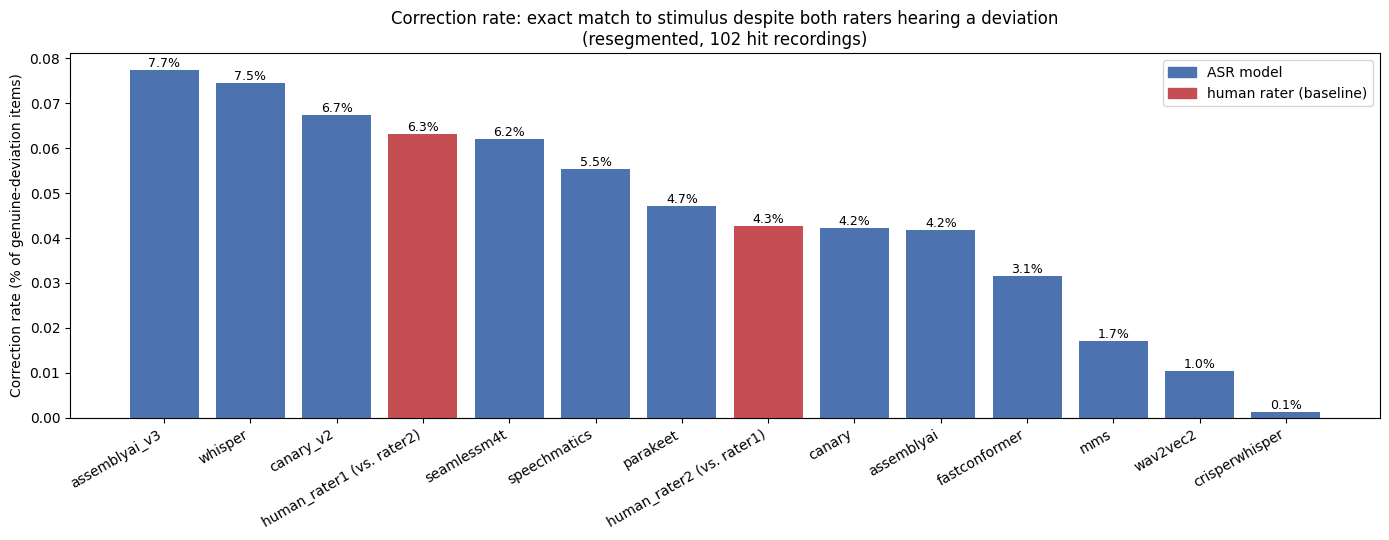

In [6]:
def plot_bar(series: pd.Series, title: str, ylabel: str, save_path: str, pct: bool = False) -> None:
    order = series.index.tolist()
    is_human = ["human_rater" in s for s in order]
    colors = ["#C44E52" if h else "#4C72B0" for h in is_human]

    fig, ax = plt.subplots(figsize=(max(12, len(order) * 1.0), 5.5))
    bars = ax.bar(range(len(order)), series.values, color=colors)
    for b, v in zip(bars, series.values):
        label = f"{v:.1%}" if pct else f"{v:.3f}"
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), label, ha="center",
                 va="bottom" if v >= 0 else "top", fontsize=9)

    ax.axhline(0, color="#999999", linewidth=0.8)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=30, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(handles=[
        plt.Rectangle((0, 0), 1, 1, color="#4C72B0", label="ASR model"),
        plt.Rectangle((0, 0), 1, 1, color="#C44E52", label="human rater (baseline)"),
    ], loc="upper right")
    fig.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


plot_bar(
    stats["correction_rate"].sort_values(ascending=False),
    "Correction rate: exact match to stimulus despite both raters hearing a deviation\n(resegmented, 102 hit recordings)",
    "Correction rate (% of genuine-deviation items)",
    "../plots/stimulus_correction_rate.png",
    pct=True,
)

## Plot 2: Near-exact correction rate (WER vs. stimulus ≤ 0.15), more statistical power

The raw mean "stimulus pull" (`rater distance - source distance`, averaged) turns out to be a poor
metric for this specific question: it's dominated by ordinary ASR error unrelated to correction —
e.g. `crisperwhisper`'s known repetition-loop failures (see
`docs/asr_model_comparison_analysis.md` §3.4) occasionally put it *very* far from the stimulus,
which drags its mean pull deeply negative even though its *typical* (median) item shows no pull at
all. It's kept in the `stats` table above for reference but not charted.

A tempting robust alternative — "% of items where the source lands at least as close to the
stimulus as the raters did" — turns out to be confounded with a different thing entirely: **general
transcription accuracy**, not correction specifically. Both human raters score 81–84% on that
metric, far above any model, simply because they're much more accurate transcribers of what was
actually said, which loosely tracks the stimulus anyway — that's not evidence either rater is
"correcting" toward the script.

This version stays close to Plot 1's framing (how often does the output land essentially *at* the
stimulus, not just generally *near* the truth) but relaxes exact-match to a small WER tolerance
(≤0.15, roughly "at most one word off" on a typical item), trading a little precision
for meaningfully more statistical power. The ranking is nearly identical to Plot 1's, which is
itself a good sign that the exact-match result isn't a fluke of an arbitrary all-or-nothing
threshold.


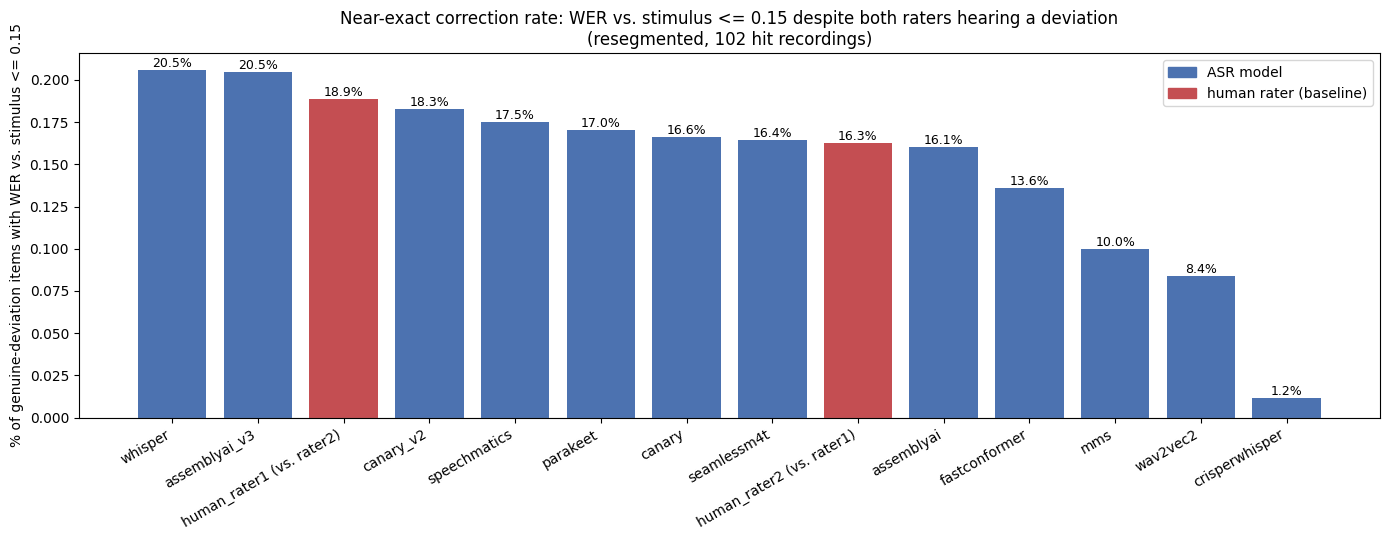

In [7]:
plot_bar(
    stats["near_correction_rate"].sort_values(ascending=False),
    f"Near-exact correction rate: WER vs. stimulus <= {NEAR_THRESHOLD} despite both raters hearing a deviation\n(resegmented, 102 hit recordings)",
    f"% of genuine-deviation items with WER vs. stimulus <= {NEAR_THRESHOLD}",
    "../plots/stimulus_correction_near_exact.png",
    pct=True,
)


## Plot 3: Per-item scatter, four illustrative sources

One point per genuine-deviation item: x = average rater distance to the stimulus, y = the source's
own distance to the stimulus. Points **on** the diagonal track the raters' own distance from the
stimulus; points **below** it are closer to the stimulus than the raters were (consistent with, but
not on their own proof of, correction — see Plot 1/2 for the actual conditioned statistics). A
handful of severe insertion-heavy items push WER past 1.0 (unbounded above); axes are clipped to
[0, 1.5] (covering ~95% of points for every source shown) so the bulk of the distribution is
actually visible rather than compressed into a corner by a few outliers.

Four sources chosen to span the hypotheses this project has tested: `whisper` (the model with the
most-discussed implicit fluency prior), `assemblyai_v3` (the model added specifically for
disfluency-preserving *prompting*), `speechmatics` (the best system on WER, architecture
undisclosed), and `fastconformer` (a pure CTC model with no autoregressive decoder — the
"can't smooth toward fluency even in principle" control from `docs/asr_model_comparison_analysis.md`
§4.1).


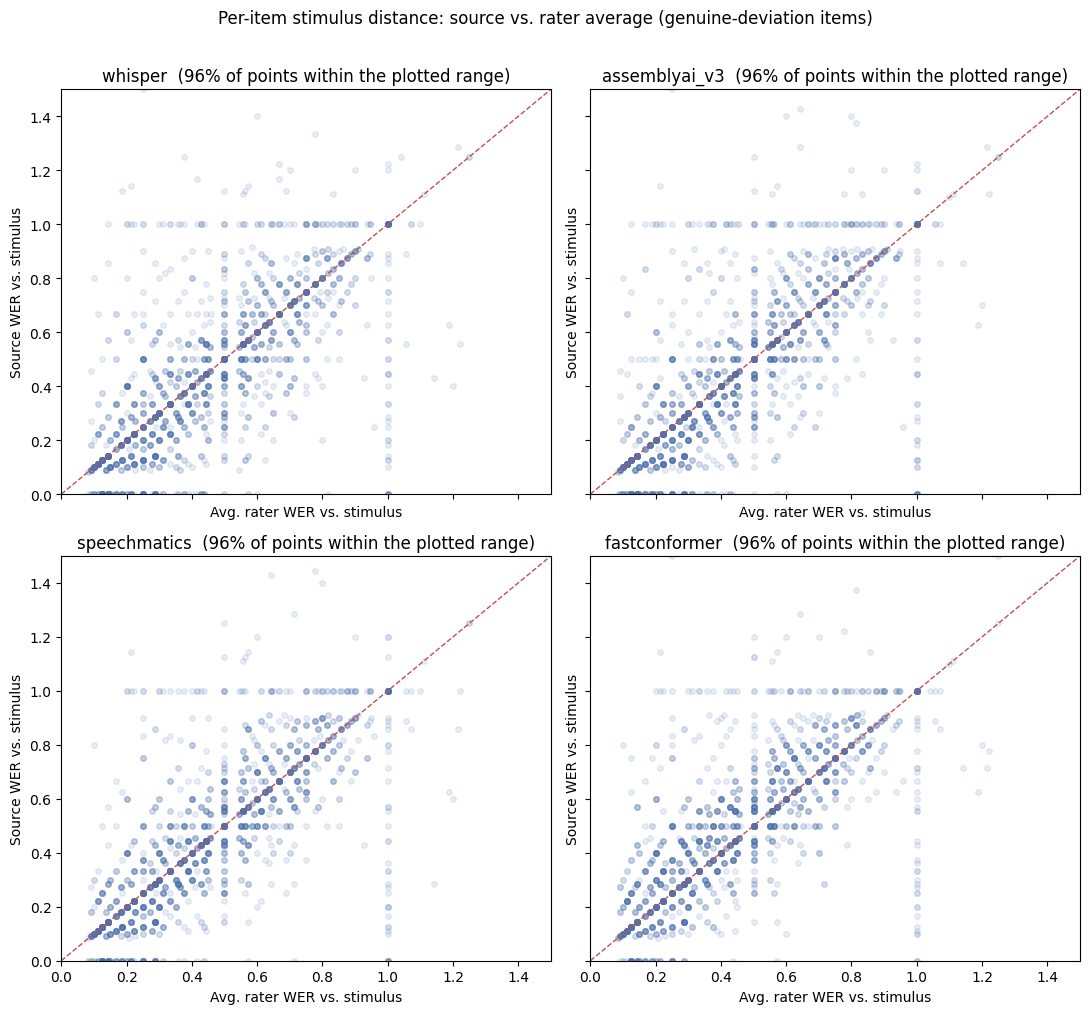

In [8]:
SCATTER_SOURCES = ["whisper", "assemblyai_v3", "speechmatics", "fastconformer"]
AXIS_LIMIT = 1.5

rater_avg = (genuine_deviation["human_rater1_wer_vs_stimulus"] + genuine_deviation["human_rater2_wer_vs_stimulus"]) / 2

fig, axes = plt.subplots(2, 2, figsize=(11, 10), sharex=True, sharey=True)
for ax, source in zip(axes.flat, SCATTER_SOURCES):
    y = genuine_deviation[f"{source}_wer_vs_stimulus"]
    ax.scatter(rater_avg, y, alpha=0.12, s=16, color="#4C72B0")
    ax.plot([0, AXIS_LIMIT], [0, AXIS_LIMIT], color="#C44E52", linewidth=1, linestyle="--")
    shown = ((rater_avg <= AXIS_LIMIT) & (y <= AXIS_LIMIT)).mean()
    ax.set_title(f"{source}  ({shown:.0%} of points within the plotted range)")
    ax.set_xlabel("Avg. rater WER vs. stimulus")
    ax.set_ylabel("Source WER vs. stimulus")
    ax.set_xlim(0, AXIS_LIMIT)
    ax.set_ylim(0, AXIS_LIMIT)

fig.suptitle("Per-item stimulus distance: source vs. rater average (genuine-deviation items)", y=1.01)
fig.tight_layout()
plt.savefig("../plots/stimulus_correction_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


## Takeaways

- **`whisper` and `assemblyai_v3` are the two clearest cases of a model "correcting" the learner
  back to the script**, and they clear the human noise floor by a real margin, not a rounding
  error. Both raters' own baseline correction rate sits at 4.3–6.3% (how often one rater's
  transcript exactly matches the stimulus despite the *other*, independent rater hearing a
  deviation); `whisper` (7.5%) and `assemblyai_v3` (7.7%) both sit clearly above even the higher of
  the two rater baselines. The near-exact version (WER ≤ 0.15) tells the same story with more
  data behind it: both at 20.5%, vs. 16.3–18.9% for the raters.
- **`canary_v2` is a weaker, second-tier case** — 6.7% / 18.3%, close to (and on the near-exact
  metric, slightly below) `human_rater1`'s own baseline. Worth noting rather than treating as
  established.
- **Every other model sits at or below the human noise floor** — `speechmatics` (5.5% / 17.5%,
  despite being the best system on aggregate WER — being accurate and being prone to
  script-correction are evidently different things), `canary`, `assemblyai` (Universal-2,
  unprompted), `fastconformer`, `parakeet`, `seamlessm4t` all land in a band indistinguishable from
  ordinary human transcription variance. `mms`, `wav2vec2`, and especially `crisperwhisper`
  (0.1% / 1.2%) are, if anything, the *opposite* of correcting — they diverge from the stimulus
  even more than typical ASR error would predict, consistent with `crisperwhisper`'s known
  verbatim-training-induced garbling (`docs/asr_model_comparison_analysis.md` §3.4) rather than any
  fluency-smoothing behavior.
- **This directly sharpens the open question in `docs/asr_model_comparison_analysis.md` §4.1**
  ("does an attention decoder inherently correct disfluent speech?", answered there as "not a
  clean causal chain" using aggregate WER/MER/CER, which can't distinguish correction from any
  other source of accuracy). This notebook's conditioned, item-level check finds real, if modest,
  evidence *for* the hypothesis specifically for `whisper` — consistent with §4.1's own discussion
  of Whisper's documented hallucination-toward-fluency behavior (§3.1), just not previously
  isolated from its overall WER. `assemblyai_v3` joining it is new: its prompt explicitly asks the
  model to *preserve* disfluencies, yet it shows the single highest correction rate of any of the
  twelve systems — worth flagging directly, since it cuts against the intent of the prompt that
  helped it win on every other metric (§3.12, §4.6).
- **`fastconformer` (no autoregressive decoder, can't smooth toward fluency even in principle,
  §4.1's architectural control) sits below the human floor on both metrics (3.2% / 13.6%)** — the
  cleanest single piece of evidence in this notebook that decoder architecture, not just
  training data or vendor, plausibly matters for this specific behavior, consistent with §4.1's
  broader conclusion.
- **Caveat on sample size and multiple comparisons:** these are 12 model rates compared against a
  ~5% human floor from ~2,200–2,370 items each; the gaps for the top two models (whisper,
  assemblyai_v3) are real but not huge (2–3 points above the higher rater baseline on the strict
  metric). Treat this as suggestive, reproducible evidence worth watching across future model
  additions to this harness, not as a settled statistical claim with a computed significance test.
